# Women at Work: South Asia Policy Analysis (2000–2024)

Author: Aradhya  
Date: July 2026

This notebook analyzes Female Labour Force Participation (FLFP) trends across
eight South Asian countries using World Bank Development Indicators (ILO-modelled
estimates) from 2000–2024.

In [ ]:
"""
Women at Work: South Asia Policy Analysis (2000–2024)

This notebook analyzes Female Labour Force Participation (FLFP) trends across
eight South Asian countries using World Bank Development Indicators (ILO-modelled
estimates) from 2000 to 2024.

Workflow:
1. Import World Bank FLFP and metadata files.
2. Clean and prepare the dataset.
3. Merge country metadata.
4. Reshape the data into long format.
5. Handle missing values and create an analysis-ready dataset.
6. Generate comparative visualizations.
7. Summarize findings through a policy brief.

"""

In [9]:
import os
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (skipping the 4 rows of World Bank metadata)
df = pd.read_csv('API_SL.TLF.CACT.FE.ZS_DS2_en_csv_v2_33796.csv', skiprows=4)

# 2. head(): View the first 5 rows to ensure it loaded properly
print("--- FIRST 5 ROWS ---")
display(df.head())

# 3. info(): Inspect the columns, non-null counts, and data types
print("\n--- DATA INFO ---")
df.info()

# 4. describe(): Get a high-level statistical summary of the dataset
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- FIRST 5 ROWS ---


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,61.840882,61.261836,60.669809,59.433681,59.454457,59.831305,63.592598,63.643292,63.674180,NaN
2,Afghanistan,AFG,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,21.240000,19.805000,18.298000,16.474000,14.616000,5.159000,5.145000,5.123000,5.086000,NaN
3,Africa Western and Central,AFW,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,66.201518,65.898513,65.669365,64.380087,65.070247,65.693357,67.351964,67.358612,67.256308,NaN
4,Angola,AGO,"Labor force participation rate, female (% of f...",SL.TLF.CACT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,73.461000,73.224000,72.985000,71.342000,74.695000,74.018000,72.318000,72.359000,72.224000,NaN



--- DATA INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    265 non-null    str    
 1   Country Code    265 non-null    str    
 2   Indicator Name  265 non-null    str    
 3   Indicator Code  265 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null 

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,234.000000,234.000000,234.000000,234.000000,234.000000,233.000000,231.000000,229.000000,229.000000,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,50.352060,50.368613,50.440247,49.210483,49.809522,50.328160,51.028439,51.103211,51.017334,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.573662,14.642480,14.694139,14.653969,14.759029,14.979993,14.763177,14.612636,14.594132,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.041000,4.987000,4.937000,4.899000,4.875000,4.801000,4.752000,4.705000,4.663000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.805000,44.806500,44.710250,42.789000,43.341000,43.957000,44.497000,45.428000,46.017000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,52.069978,52.206071,52.470000,51.100500,51.739500,52.281000,52.773000,52.784000,52.768000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,58.983331,59.225810,59.545314,58.161103,58.896404,59.551000,59.948000,59.473000,59.454000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,83.044000,82.971000,82.916000,82.152000,82.807000,82.830000,82.866000,82.915000,82.913000,NaN


In [ ]:
# 5. loc[]: Filter out the specific South Asian countries and grab the years 2000 to 2024
south_asia_countries = ['India',
                        'Pakistan', 
                        'Bangladesh', 
                        'Sri Lanka', 
                        'Nepal', 
                        'Bhutan', 
                        'Maldives', 
                        'Afghanistan']

# Generate a list of years as strings (since World Bank column headers are strings)
years = [str(year) for year in range(2000, 2025)]

# Use loc to filter rows (by Country Name) and select specific columns
sa_df = df.loc[df['Country Name'].isin(south_asia_countries),
                 ['Country Name', 'Country Code'] + years]

print("--- South Asia Filtered Data (using loc) ---")
display(sa_df)

# 6. iloc[]: Select data strictly by integer position index
# Let's grab the first 3 rows and the first 5 columns of our
# new South Asia dataframe to prove we know how iloc works
print("\n--- Slice of Data (using iloc) ---")
display(sa_df.iloc[0:3, 0:5])

--- South Asia Filtered Data (using loc) ---


,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,Afghanistan,AFG,14.294,14.196,14.152,14.154,14.205,14.302,14.452,14.670,...,19.113,20.156,21.240,19.805,18.298,16.474,14.616,5.159,5.145,5.123
20,Bangladesh,BGD,28.671,28.878,28.980,29.055,29.123,29.194,29.241,30.797,...,33.531,33.497,36.676,38.056,39.330,40.323,42.181,43.687,41.874,38.708
32,Bhutan,BTN,59.314,60.142,61.032,61.960,62.923,63.749,64.326,64.807,...,54.976,54.892,54.815,54.743,60.631,63.002,64.902,52.510,56.618,56.636
108,India,IND,34.397,34.483,34.570,34.660,34.753,34.852,33.499,32.179,...,26.582,26.575,26.578,26.568,26.539,25.998,27.724,29.348,30.984,32.415
137,Sri Lanka,LKA,36.331,36.077,35.831,35.590,35.350,35.111,34.876,34.644,...,35.330,35.252,36.094,33.105,34.051,31.663,31.329,31.605,29.600,30.998
151,Maldives,MDV,37.037,37.045,37.054,37.061,37.065,37.066,36.958,36.730,...,38.573,38.986,39.781,40.382,40.760,37.104,37.995,40.171,40.311,40.455
177,Nepal,NPL,21.283,21.497,21.723,21.954,22.211,22.502,22.826,23.184,...,27.006,27.346,27.530,27.628,27.537,27.209,27.256,27.240,27.302,27.378
183,Pakistan,PAK,16.130,16.170,16.224,16.995,17.777,18.348,18.947,19.308,...,23.983,23.162,22.358,21.571,23.241,23.406,24.365,24.027,23.997,23.989



--- Slice of Data (using iloc) ---


,Country Name,Country Code,2000,2001,2002
2,Afghanistan,AFG,14.294,14.196,14.152
20,Bangladesh,BGD,28.671,28.878,28.980
32,Bhutan,BTN,59.314,60.142,61.032


In [ ]:
# 7. isnull(): Check if there are missing values in our South-Asia dataset
print("--- Missing Values Count Per Column ---")
display(sa_df.isnull().sum())

# 8. fillna(): Handle any gaps by filling missing data with 0
# (In a rigorous study, you might use forward-fill or mean, but 0 works perfectly for this exercise)
sa_df_clean = sa_df.fillna(0)

print("\n--- Missing Values Count After fillna() ---")
display(sa_df_clean.isnull().sum())

# 9. value_counts(): Verify how many data entries we have per country to ensure no duplicates
print("\n--- Country Row Counts ---")
display(sa_df_clean['Country Name'].value_counts())

--- Missing Values Count Per Column ---


Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
2023            0
2024            0
dtype: int64


--- Missing Values Count After fillna() ---


Country Name    0
Country Code    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
2023            0
2024            0
dtype: int64


--- Country Row Counts ---


Country Name
Afghanistan    1
Bangladesh     1
Bhutan         1
India          1
Sri Lanka      1
Maldives       1
Nepal          1
Pakistan       1
Name: count, dtype: int64

In [ ]:

# 10. merge(): Load the helper metadata file and combine it with your main dataframe
# This file contains the 'Region' mappings for every country in the world
metadata_df = pd.read_csv('Metadata_Country_API_SL.TLF.CACT.FE.ZS_DS2_en_csv_v2_33796.csv')

# Merge them together using the matching 'Country Code' column
merged_df = pd.merge(df, metadata_df, on='Country Code')

# 11. groupby(): Group the merged dataset by 'Region' to see how
# South Asia compares globally in 2023
# (Note: World Bank data for the current year, 2024, is often blank,
# so we'll use 2024 for the global comparison)
print("--- Average Female Labor Force Participation by Region (2024) ---")
regional_analysis = merged_df.groupby('Region')['2024'].mean().reset_index()
display(regional_analysis)

# 12. sort_values(): Sort the South Asian countries from
# highest to lowest participation rate in 2023
print("\n--- South Asian Countries Ranked by 2024 Participation Rate ---")
sa_ranked = sa_df_clean.sort_values(by='2024', ascending=False)
display(sa_ranked[['Country Name', '2024']])

--- Average Female Labor Force Participation by Region (2024) ---

,Region,2024
0,East Asia & Pacific,56.663586
1,Europe & Central Asia,53.320500
2,Latin America & Caribbean,52.324677
3,Middle East & North Africa,28.809143
4,North America,58.488000
5,South Asia,37.765000
6,Sub-Saharan Africa,57.701000



--- South Asian Countries Ranked by 2024 Participation Rate ---


,Country Name,2024
32,Bhutan,56.636
151,Maldives,40.455
20,Bangladesh,38.708
108,India,32.415
137,Sri Lanka,30.998
177,Nepal,27.378
183,Pakistan,23.989
2,Afghanistan,5.123


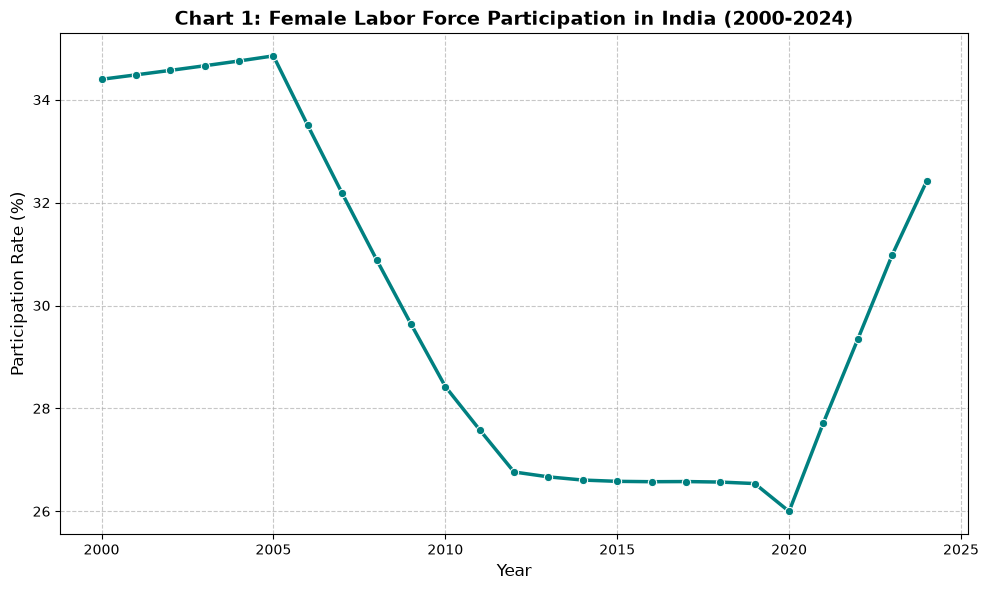

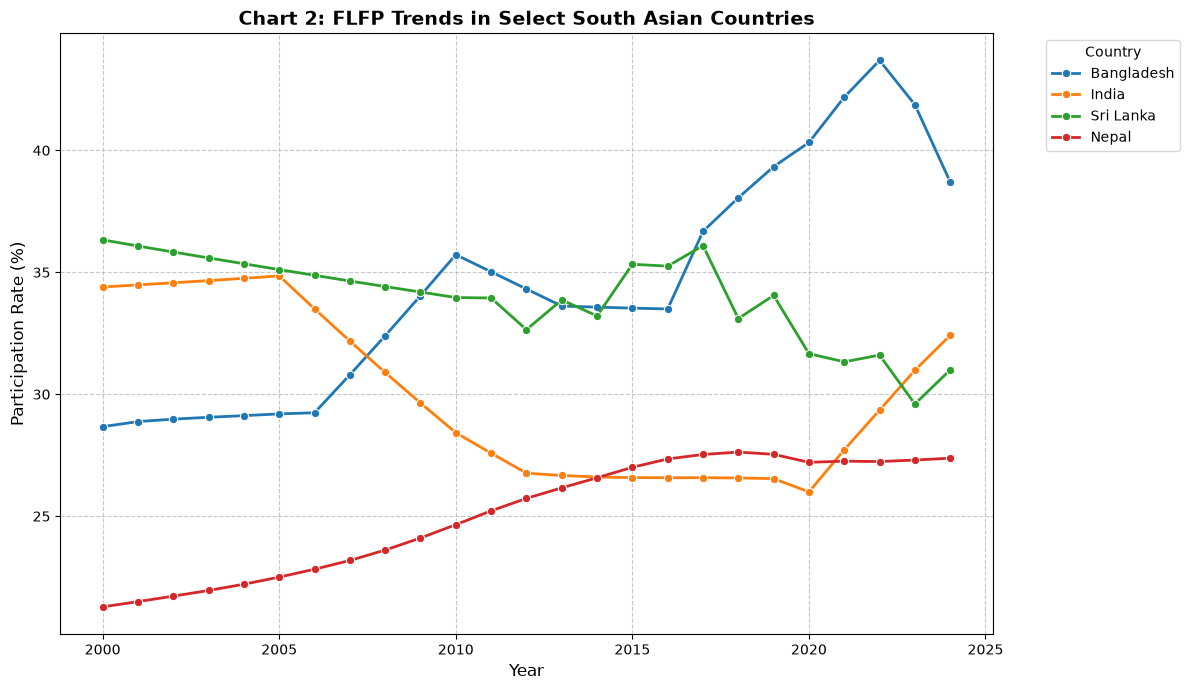

C:\Users\aradh\AppData\Local\Temp\ipykernel_36740\2071488480.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_year_df, x='2024', y='Country Name', palette='magma')


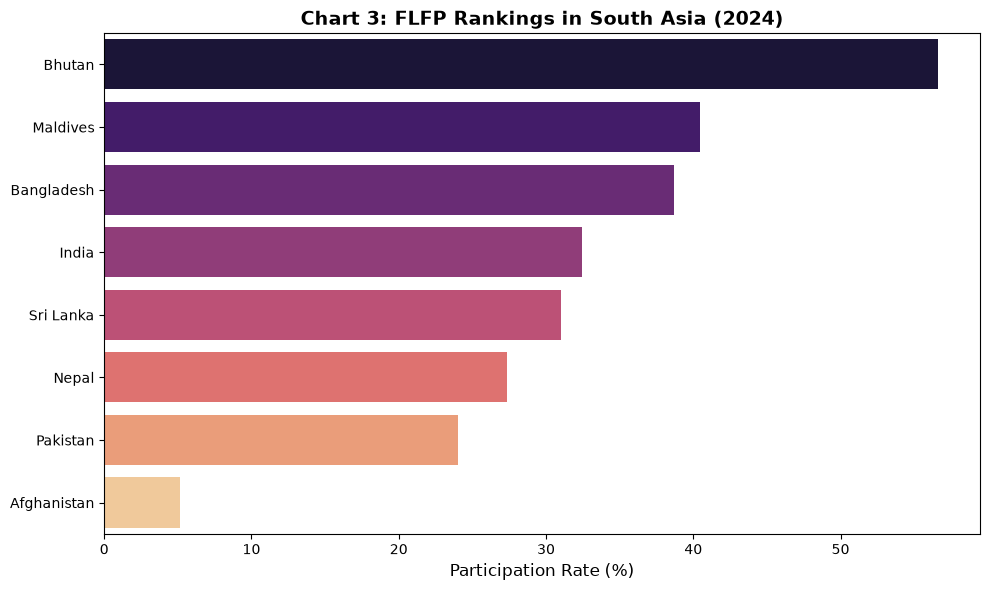

All charts generated and saved to the 'charts/' directory!


In [ ]:
# Create the 'charts' directory if it doesn't exist to match the project structure
os.makedirs('charts', exist_ok=True)

# 13. Reshape the data for easier plotting (wide to long format)
# Melt the dataframe so 'Year' becomes a single column
years = [str(year) for year in range(2000, 2025)]
melted_df = sa_df_clean.melt(id_vars=['Country Name', 'Country Code'],
                             value_vars=years,
                             var_name='Year',
                             value_name='FLFP_Rate')

# This converts Year column to numbers so the X-axis plots correctly
melted_df['Year'] = pd.to_numeric(melted_df['Year'])


# --- CHART 1: India Over Time ---
plt.figure(figsize=(10, 6))
india_df = melted_df[melted_df['Country Name'] == 'India']
sns.lineplot(data=india_df, x='Year', y='FLFP_Rate', color='teal', linewidth=2.5, marker='o')

plt.title('Chart 1: Female Labor Force Participation in India (2000-2024)',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Participation Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('charts/chart1.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


# --- CHART 2: Comparative Trends ---
plt.figure(figsize=(12, 7))
target_countries = ['India', 'Bangladesh', 'Nepal', 'Sri Lanka']
comparison_df = melted_df[melted_df['Country Name'].isin(target_countries)]

sns.lineplot(data=comparison_df,
             x='Year',
             y='FLFP_Rate',
             hue='Country Name',
             linewidth=2,
             marker='o')

plt.title('Chart 2: FLFP Trends in Select South Asian Countries', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Participation Rate (%)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('charts/chart2.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


# --- CHART 3: Latest Available Year (2024) Rankings ---
plt.figure(figsize=(10, 6))

# Sort the 2024 data from highest to lowest
latest_year_df = sa_df_clean[['Country Name', '2024']].sort_values(by='2024', ascending=False)

sns.barplot(data=latest_year_df, x='2024', y='Country Name', palette='magma')

plt.title('Chart 3: FLFP Rankings in South Asia (2024)', fontsize=14, fontweight='bold')
plt.xlabel('Participation Rate (%)', fontsize=12)
plt.ylabel('') # Leave y-axis label blank for a cleaner look

plt.tight_layout()
plt.savefig('charts/chart3.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("All charts generated and saved to the 'charts/' directory!")

In [14]:
# Export the cleaned dataset to a CSV file
sa_df_clean.to_csv('cleaned_data.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!
